In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import torch.nn.functional as F
from sklearn.manifold import TSNE

sys.path.append('../') 
try:
    from NeuroHDC.FHRR import *
    from NeuroHDC.fn import *
    from conformalHDC.models import *
    from conformalHDC.methods import *
    from conformalHDC.utils import *
except ImportError:
    print("Warning: NeuroHDC or conformalHDC modules not found. Ensure '../' is in path.")

In [18]:
def get_random_unit_vector(dim, rng):
    """Generates a random unit vector in D-dimensions."""
    v = rng.randn(dim)
    return v / np.linalg.norm(v)

def sample_filled_ball(n_samples, dim, center, radius, rng):
    """
    Samples points with a linear radius distribution (Uniform[0, radius]),
    creating a visually 'filled' ball (dense center) rather than a hollow shell.
    """
    # 1. Random Directions
    dirs = rng.randn(n_samples, dim)
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    
    # 2. Random Radii (Linear distribution U[0, 1] * R)
    radii = rng.uniform(0, 1, size=(n_samples, 1)) * radius
    
    return center + dirs * radii

def generate_inlier_balls(n_samples, dim, radius_tight, expansion_factor, rng, scale=10):
    """
    Generates two inlier classes with a fixed center distance.
    
    - Distance is fixed at 2 * radius_tight.
    - If expansion_factor == 1.0: Balls just touch.
    - If expansion_factor > 1.0: Class 1 grows and overlaps Class 0.
    """
    # 1. Define Centers
    mu0 = np.zeros(dim)
    
    # Random axis for high-dim realism
    axis_direction = get_random_unit_vector(dim, rng)
    
    effective_dist = (2.0 * radius_tight) * (scale / np.sqrt(dim))    
    mu1 = mu0 + axis_direction * effective_dist
    
    # 2. Sample Class 0 (Tight)
    X0 = sample_filled_ball(n_samples, dim, mu0, radius_tight, rng)
    
    # 3. Sample Class 1 (Expanding / Trap)
    radius_loose = radius_tight * expansion_factor
    X1 = sample_filled_ball(n_samples, dim, mu1, radius_loose, rng)
    
    # 4. Combine
    X = np.concatenate([X0, X1]).astype(np.float32)
    y = np.concatenate([np.zeros(n_samples), np.ones(n_samples)]).astype(int)
    
    return X, y, mu0, mu1

def generate_ood_ball(n_samples, dim, mu0, mu1, distance_scale, rng, radius=None):
    """
    Generates OOD samples in a ball orthogonal to the inlier axis.
    distance_scale controls how far from the midpoint (relative to inlier size).
    """
    # 1. Analyze Geometry
    axis_vector = mu1 - mu0
    base_dist = np.linalg.norm(axis_vector) # This is 2*radius_tight
    axis_unit = axis_vector / base_dist
    midpoint = (mu0 + mu1) / 2.0
    
    # Default OOD radius to match the tight class size (base_dist / 2)
    if radius is None:
        radius = base_dist / 2.0 

    # 2. Find Orthogonal Direction
    # Generate random vec, subtract projection onto axis
    rand_vec = rng.randn(dim)
    orth_vec = rand_vec - np.dot(rand_vec, axis_unit) * axis_unit
    orth_vec /= np.linalg.norm(orth_vec)
    
    # 3. Define OOD Center 
    # Move out from midpoint. 
    # scale=1.0 puts center roughly 2R away from inlier centers.
    mu_ood = midpoint + orth_vec * (base_dist * distance_scale)
    
    # 4. Sample
    X_ood = sample_filled_ball(n_samples, dim, mu_ood, radius, rng)
    
    return X_ood.astype(np.float32)

def visualize_tsne(X_in, y_in, X_ood, title="t-SNE Visualization"):
    """
    Runs t-SNE on Inliers + OOD and plots them.
    """
    # Combine Data
    X_all = np.concatenate([X_in, X_ood])
    # Label 2 for OOD
    y_all = np.concatenate([y_in, np.full(len(X_ood), 2)])
    
    print(f"Running t-SNE on {len(X_all)} samples (Dim={X_all.shape[1]})...")
    
    # Perplexity 30 is standard. Lower (e.g. 10-20) emphasizes local clusters more.
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    X_emb = tsne.fit_transform(X_all)
    
    # Plot
    plt.figure(figsize=(10, 8))
    
    # Class 0: Blue (Tight)
    mask0 = y_all == 0
    plt.scatter(X_emb[mask0, 0], X_emb[mask0, 1], c='blue', label='Class 0 (Tight)', s=20, alpha=0.6)
    
    # Class 1: Red (Expanding/Trap)
    mask1 = y_all == 1
    plt.scatter(X_emb[mask1, 0], X_emb[mask1, 1], c='red', label='Class 1 (Expanding)', s=20, alpha=0.6)
    
    # OOD: Green
    mask_ood = y_all == 2
    plt.scatter(X_emb[mask_ood, 0], X_emb[mask_ood, 1], c='green', label='OOD', s=30, alpha=0.7, marker='^')
    
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks([]); plt.yticks([])
    plt.show()

Running t-SNE on 1500 samples (Dim=10000)...


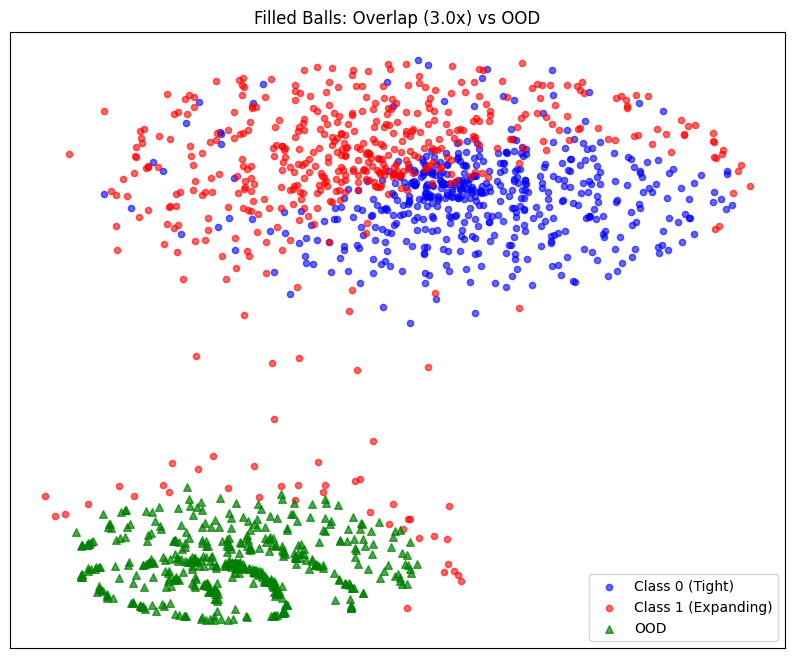

In [19]:
RNG = np.random.RandomState(42)
DIM = 10000
N = 500
R_TIGHT = 1.0

# 1. Generate Inliers (Class 1 is 3x larger -> Overlap)
X_in, y_in, m0, m1 = generate_inlier_balls(N, DIM, radius_tight=R_TIGHT, expansion_factor=3.0, rng=RNG, scale=1)

# 2. Generate OOD 
# scale=2.0 moves it comfortably away from the overlapping mess
X_ood = generate_ood_ball(N, DIM, m0, m1, distance_scale=3.0, rng=RNG)

# 3. Visualize
visualize_tsne(X_in, y_in, X_ood, title="Filled Balls: Overlap (3.0x) vs OOD")

In [20]:
def run_single_experiment(seed, sigma_loose):
    rng = np.random.RandomState(seed)
    
    # ==========================================
    # 1. SAMPLE FULL DATASET & SPLIT
    # ==========================================
    # Calculate total samples needed
    n_total_per_class = SAMPLES_TRAIN + SAMPLES_CAL + SAMPLES_TEST
    
    # Generate the large pool (Sample First)
    # This ensures consistency: all splits come from the exact same geometry instance
    X_full, y_full, mu0, mu1 = generate_inlier_balls(
        n_total_per_class, DIM, SIGMA_TIGHT, sigma_loose, rng
    )
    
    # OOD is independent, but uses the same geometry (mu0, mu1)
    X_ood = generate_ood_ball(500, DIM, mu0, mu1, OOD_DISTANCE, rng)

    # Splitting Logic
    # We perform a random shuffle to ensure IID splits
    indices = np.arange(len(X_full))
    rng.shuffle(indices)
    
    # Calculate split points (Total dataset size is 2 * n_total_per_class because of 2 classes)
    total_samples = len(X_full)
    n_train_total = SAMPLES_TRAIN * 2
    n_cal_total   = SAMPLES_CAL * 2
    
    idx_train = indices[:n_train_total]
    idx_cal   = indices[n_train_total : n_train_total + n_cal_total]
    idx_test  = indices[n_train_total + n_cal_total :]
    
    X_train, y_train = X_full[idx_train], y_full[idx_train]
    X_cal,   y_cal   = X_full[idx_cal],   y_full[idx_cal]
    X_test,  y_test  = X_full[idx_test],  y_full[idx_test]

    unique_labels = [0, 1]

    # ==========================================
    # 2. TRAIN MODELS
    # ==========================================
    
    # Helper to compute prototypes from a specific set of data
    def fit_prototypes(X, y):
        protos = []
        for label in unique_labels:
            class_vectors = X[y == label]
            if len(class_vectors) == 0:
                # Fallback if split unlucky (rare with balanced generation)
                protos.append(np.zeros(X.shape[1])) 
            else:
                protos.append(np.mean(class_vectors, axis=0))
        return np.stack(protos)

    # Model A: ConformalHDC (Uses ONLY Train for prototypes)
    protos_conformal = fit_prototypes(X_train, y_train)
    chdc = ConformalHDC(class_HVs=protos_conformal, class_labels=unique_labels, 
                        sim_measure="euclidean", random_state=seed)
    
    # Model B: Vanilla HDC (Uses Train + Cal for prototypes)
    X_vanilla = np.concatenate([X_train, X_cal])
    y_vanilla = np.concatenate([y_train, y_cal])
    protos_vanilla = fit_prototypes(X_vanilla, y_vanilla)
    
    # We instantiate a separate "Vanilla" model just to use its predict method correctly
    # with the better prototypes
    vanilla_model = ConformalHDC(class_HVs=protos_vanilla, class_labels=unique_labels,
                                 sim_measure="euclidean", random_state=seed)

    # ==========================================
    # 3. RUN EXPERIMENT LOOP
    # ==========================================
    exp_results = []

    # Loop Score Types (for Conformal)
    for stype in SCORE_TYPES:
        # Calibrate on Cal Set
        chdc.compute_calib_scores(X_cal, y_cal, score_type=stype)
        
        # A. Set-Valued Prediction
        for marginal in [True, False]:
            sets = chdc.set_valued_CP(X_test, ALPHA, marginal=marginal)
            sizes = [len(p) for p in sets]
            covered = [1 if y in p else 0 for y, p in zip(y_test, sets)]
            
            # Label conditional coverage
            lc_covs = []
            for lbl in unique_labels:
                lbl_idx = np.where(y_test == lbl)[0]
                if len(lbl_idx) > 0:
                    lc_covs.append(np.mean([covered[i] for i in lbl_idx]))
            
            exp_results.append({
                "sigma_loose": sigma_loose,
                "score_type": stype,
                "exp": "set_valued",
                "marginal": marginal,
                "set_cov": np.mean(covered),
                "set_size": np.mean(sizes),
                "min_class_cov": np.min(lc_covs) if lc_covs else 0.0,
                "point_acc": np.nan, "ood_auroc": np.nan
            })
        
        # B. Point-Valued Prediction (Conformal Model)
        preds_pt = chdc.point_valued_CP(X_test, 0.05, allow_empty=False, marginal=False)
        acc_pt = accuracy_score(y_test, np.array(preds_pt).ravel())
        
        exp_results.append({
            "sigma_loose": sigma_loose,
            "score_type": stype,
            "exp": "point_valued",
            "point_acc": acc_pt,
            "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
            "min_class_cov": np.nan, "ood_auroc": np.nan
        })
        
        # C. OOD Detection
        for marginal in [True, False]:
            p_vals_id = chdc.get_max_p_value(X_test, marginal=marginal)
            p_vals_ood = chdc.get_max_p_value(X_ood, marginal=marginal)
            
            y_true_roc = np.concatenate([np.ones(len(p_vals_id)), np.zeros(len(p_vals_ood))])
            y_scores_roc = np.concatenate([p_vals_id, p_vals_ood])
            
            # Safe ROC calc
            if len(np.unique(y_true_roc)) > 1:
                ood_auroc = roc_auc_score(y_true_roc, y_scores_roc)
            else:
                ood_auroc = 0.5
            
            exp_results.append({
                "sigma_loose": sigma_loose,
                "score_type": stype,
                "exp": "ood",
                "marginal": marginal,
                "ood_auroc": ood_auroc,
                "set_cov": np.nan, "set_size": np.nan, "point_acc": np.nan, 
                "min_class_cov": np.nan
            })

    # 4. Baseline Vanilla HDC (Using the stronger prototypes)
    preds_vanilla = vanilla_model.predict(X_test)
    acc_vanilla = accuracy_score(y_test, preds_vanilla)
    
    exp_results.append({
        "sigma_loose": sigma_loose,
        "score_type": "vanilla",
        "exp": "point_valued",
        "point_acc": acc_vanilla,
        "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
        "min_class_cov": np.nan, "ood_auroc": np.nan
    })
    
    return pd.DataFrame(exp_results)

NameError: name 'final_df' is not defined

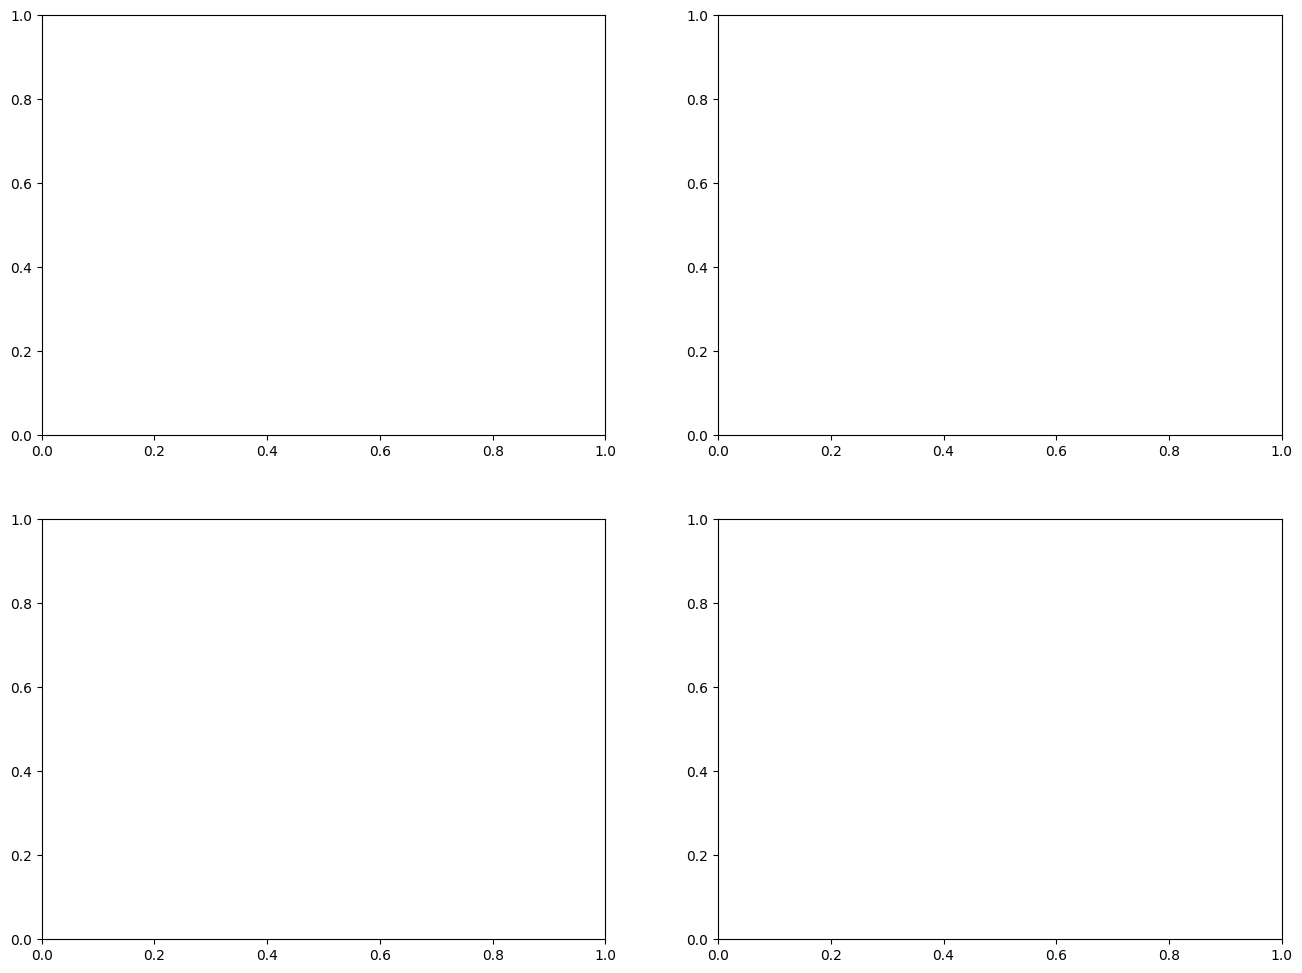